In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from scipy.integrate import quad, trapz

In [3]:
alphas = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
    2,
]

In [7]:
# Extract phases from results in other scripts

phases_1 = [
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
]

In [8]:
phases_2 = [
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    3.14159265,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
]

In [9]:
berry_phases = [phases_1, phases_2]

[[1.28866131e-17 1.28866131e-17 1.28866131e-17 1.28866131e-17
  1.28866131e-17 1.28866131e-17 1.28866131e-17 1.28866131e-17
  1.28866131e-17 1.28866131e-17 9.86960440e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.28866131e-17 1.28866131e-17 1.28866131e-17 1.28866131e-17
  1.28866131e-17 1.28866131e-17 1.28866131e-17 1.28866131e-17
  1.28866131e-17 1.28866131e-17 9.86960440e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]]


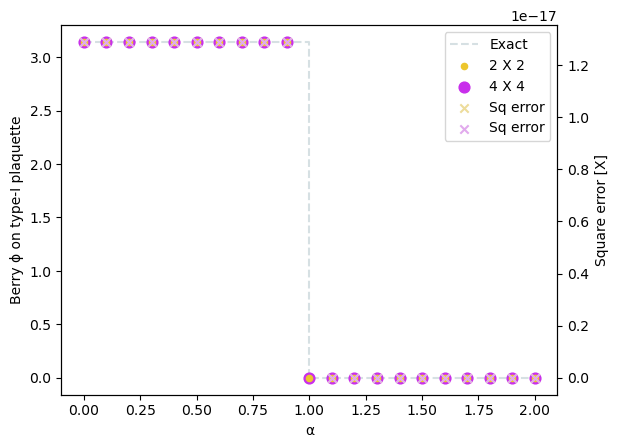

In [15]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.278, 0.804, 0.949)
c4e = (0.631, 0.867, 0.929)

c6 = (0.784, 0.18, 0.922)
c6e = (0.882, 0.667, 0.929)

c8 = (0.929, 0.776, 0.173)
c8e = (0.929, 0.863, 0.608)

# Create the first plot
fig, ax1 = plt.subplots()

l = len(alphas)
systems = 2

phases_1 = np.zeros(l)
phases_2 = np.zeros(l)

exact_phases = np.zeros(l)
exact_phases[0 : int(l / 2)+1] = np.pi

square_error_exact = np.zeros((systems, l))

for i in range(systems):
    for j in range(l):
        square_error_exact[i][j] = (exact_phases[j] - berry_phases[i][j])**2

print(square_error_exact)

square_error_exact[0][10] = None
square_error_exact[1][10] = None

p0 = ax1.step(alphas, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(alphas, berry_phases[0], color=c8, label="2 X 2", zorder=4, s=20)
p2 = ax1.scatter(alphas, berry_phases[1], color=c6, label="4 X 4", zorder=3, s=60)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p3 = ax2.scatter(
    alphas, square_error_exact[0], color=c8e, marker="x", zorder=1, label="Sq error"
)
p4 = ax2.scatter(
    alphas, square_error_exact[1], color=c6e, marker="x", zorder=1, label="Sq error"
)

# Labels
ax1.set_xlabel("α")
ax1.set_ylabel("Berry ϕ on type-I plaquette")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()